# Cross-Source Comparison — is it the method or the data quality?

The companion report (`cc_noise_report.ipynb`) studied a single traffic source
(Outbrain) and found that **a Random Forest on raw features is the strongest
bot/human detector**, that **Contrastive Clustering (CC) does not overtake it as
a classifier**, and that the validated label-noise scores are useful mainly as a
**triage / auditing** tool.

A natural objection is that this story might be an artefact of *one source's data
quality* rather than a property of the method. This notebook answers that
directly: it runs the **identical, leakage-free pipeline** on several **balanced**
sources — **Facebook, TikTok, Taboola**, with **Outbrain** as the reference — and
compares them on the same axes.

**Protocol (unchanged across sources).** Each source is a balanced 10k-bot /
10k-human corpus. A stratified train/test split is taken on the raw text
**before** any learned transform; TF-IDF (character n-grams), Truncated SVD and
the z-score scaler are fitted **only on the training split**. CC's positive pairs
come from HTTP-level two-view augmentations on the raw headers/request text. Every
number is saved under `results/cross_source/<source>/`.

**Honesty.** Real-data noise outputs remain *suspicion rankings* / *candidates for
review*, never "real probabilities of noise". Detector quality is established only
on the **synthetic** setting (known flip mask).


In [1]:
import os, sys, time, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))   # project root, to import src.*

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Article-grade figure style (matches cc_noise_report.ipynb)
mpl.rcParams['font.family']    = 'serif'
mpl.rcParams['font.serif']     = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['font.size']      = 11
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['figure.dpi']     = 120          # screen; saved figures use dpi=300

SOFT_BLUE, SOFT_RED, SOFT_GREEN, SOFT_ORANGE = '#6A8CAF', '#D87070', '#7FB07F', '#E0A458'
PALETTE = [SOFT_BLUE, SOFT_RED, SOFT_GREEN, SOFT_ORANGE, '#9B7FB0', '#5FA8A0']

FIG_DIR = os.path.join('..', 'results', 'figures', 'cross_source')
os.makedirs(FIG_DIR, exist_ok=True)
def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches='tight')


In [2]:
from src.experiments.source_study import run_source_study, load_source_study
from src.utils.io import load_json
print('Imports OK')


Imports OK


## 0. Run configuration

These settings keep the notebook runnable while remaining fully real (no mocking).
Each source runs the complete study — baselines, CC three-axis evaluation, the
synthetic-noise detection suite, and the real-data audit — and **persists** its
results. For final article numbers, set `SUBSAMPLE = None` (full 20k corpus per
source), add seeds, and raise `CC_EPOCHS`; the code paths are identical.

Outbrain is included as the **reference** so the single-source report and this
comparison share one consistent set of numbers.


In [3]:
SOURCES     = ['outbrain', 'facebook', 'tiktok', 'taboola']
SEEDS       = [42, 7]
SUBSAMPLE   = 4000          # per source; set None for the full 20k corpus
TEST_SIZE   = 0.3
SVD_DIM     = 64
CC_EPOCHS   = 15
CC_CLUSTERS = 4
CC_AUG      = 'medium_http_aug'
NOISE_RATES = [0.05, 0.10, 0.20]
KNN_K       = 20

print('Sources:', SOURCES, '| seeds', SEEDS, '| subsample', SUBSAMPLE)


Sources: ['outbrain', 'facebook', 'tiktok', 'taboola'] | seeds [42, 7] | subsample 4000


## 1. Load (or compute) the per-source results

The heavy compute is done **once** by `experiments/run_cross_source.py`, which
writes, per source: `classification.csv`, `clustering.csv`, `cc_probe.json`,
`synthetic_noise.csv`, `knn_comparison.csv`, `real_audit.json`, `top_suspects.csv`
and a headline `summary.json` under `results/cross_source/<source>/`.

This cell simply **loads** those saved artifacts so the notebook stays a fast,
timeout-free reporting layer. If a source has not been run yet, it falls back to
computing it inline (identical code path) and saving it. To (re)compute
everything from a terminal:

```
python experiments/run_cross_source.py --seeds 42 7 --subsample 4000
```

In [4]:
results = {}
for src in SOURCES:
    loaded = load_source_study(src)
    if loaded is not None:
        results[src] = loaded
        print(f'{src:9} loaded saved artifacts  (run by run_cross_source.py)')
    else:
        print(f'{src:9} no artifacts found - computing inline...')
        results[src] = run_source_study(
            src, seeds=SEEDS, subsample=SUBSAMPLE, test_size=TEST_SIZE, svd_dim=SVD_DIM,
            cc_clusters=CC_CLUSTERS, cc_epochs=CC_EPOCHS, cc_aug=CC_AUG,
            noise_rates=NOISE_RATES, knn_k=KNN_K, verbose=True)


outbrain  loaded saved artifacts  (run by run_cross_source.py)
facebook  loaded saved artifacts  (run by run_cross_source.py)


tiktok    loaded saved artifacts  (run by run_cross_source.py)


taboola   loaded saved artifacts  (run by run_cross_source.py)


In [5]:
# Headline summary table — one row per source
summ = pd.DataFrame([{
    'Source': r['summary']['source'].capitalize(),
    'Best classifier': r['summary']['best_classifier']['method'],
    'Best F1': f"{r['summary']['best_classifier']['f1']:.3f}",
    'RF F1': f"{r['summary']['rf_f1']:.3f}",
    'CC probe F1': f"{r['summary']['cc_probe_f1']:.3f}",
    'CC ARI': f"{r['summary']['cc_clustering_ari']:.3f}",
    'CC non-empty k': f"{r['summary']['cc_nonempty_clusters']:.1f}",
    'Ensemble noise ROC-AUC': f"{r['summary']['ensemble_noise_roc_auc']['mean']:.3f}",
    'CL flag rate': f"{r['summary']['confident_learning_flag_rate']*100:.2f}%",
} for r in results.values()]).set_index('Source')
summ


,Best classifier,Best F1,RF F1,CC probe F1,CC ARI,CC non-empty k,Ensemble noise ROC-AUC,CL flag rate
Source,,,,,,,,
Outbrain,RandomForest,0.886,0.886,0.785,0.079,4.0,0.915,0.96%
Facebook,RandomForest,0.997,0.997,0.972,0.400,4.0,0.995,0.21%
Tiktok,RandomForest,0.977,0.977,0.809,0.007,4.0,0.959,0.32%
Taboola,RandomForest,0.898,0.898,0.793,0.092,4.0,0.927,2.64%


## 2. Classification performance across sources — Evaluation B

The central question. If the Random-Forest-wins story were a data-quality
artefact, the ranking of methods would *change* from source to source. Below we
plot the test-set F1 of every detector for every source.

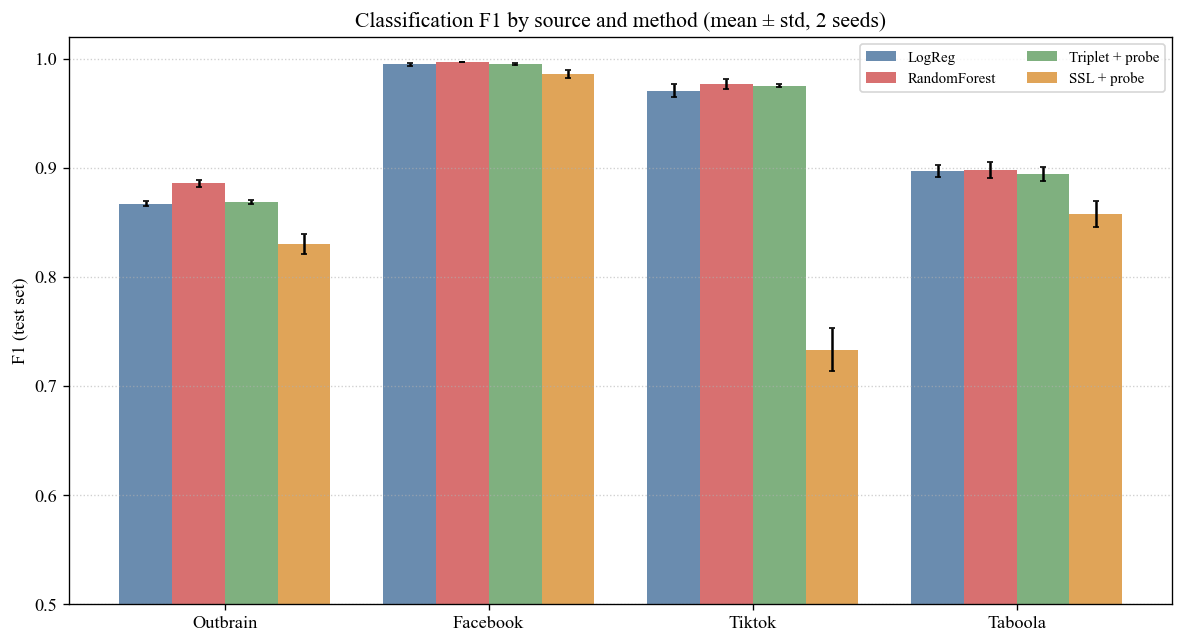

In [6]:
methods = ['LogReg', 'RandomForest', 'Triplet + probe', 'SSL + probe']
def cls_val(src, method, key='f1_mean'):
    row = next(r for r in results[src]['classification'] if r['method'] == method)
    return row[key]

x = np.arange(len(SOURCES)); w = 0.2
fig, ax = plt.subplots(figsize=(10, 5.5))
for j, m in enumerate(methods):
    means = [cls_val(s, m, 'f1_mean') for s in SOURCES]
    stds  = [cls_val(s, m, 'f1_std')  for s in SOURCES]
    ax.bar(x + (j-1.5)*w, means, w, yerr=stds, capsize=2,
           color=PALETTE[j], label=m)
ax.set_xticks(x); ax.set_xticklabels([s.capitalize() for s in SOURCES])
ax.set_ylabel('F1 (test set)'); ax.set_ylim(0.5, 1.02)
ax.set_title(f'Classification F1 by source and method (mean ± std, {len(SEEDS)} seeds)')
ax.legend(ncol=2, fontsize=9); ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout(); savefig('cs_fig1_classification_by_source.pdf'); plt.show()


In [7]:
# Full classification table (F1) — method x source
cls_tbl = pd.DataFrame({
    s.capitalize(): {m: f"{cls_val(s, m, 'f1_mean'):.3f} ± {cls_val(s, m, 'f1_std'):.3f}" for m in methods}
    for s in SOURCES})
cls_tbl.index.name = 'Method (F1)'
cls_tbl


,Outbrain,Facebook,Tiktok,Taboola
Method (F1),,,,
LogReg,0.867 ± 0.002,0.995 ± 0.001,0.970 ± 0.006,0.897 ± 0.005
RandomForest,0.886 ± 0.003,0.997 ± 0.000,0.977 ± 0.004,0.898 ± 0.007
Triplet + probe,0.869 ± 0.002,0.995 ± 0.001,0.975 ± 0.001,0.895 ± 0.007
SSL + probe,0.830 ± 0.009,0.986 ± 0.004,0.733 ± 0.020,0.858 ± 0.012


**Reading.** Read the bar heights across the four source groups. Where the
ranking of the methods is *preserved* across sources, the finding is a property of
the method, not of one source. Where the absolute F1 differs markedly between
sources (e.g. an easier source pushing every method toward 1.0), that is the
**data-quality** effect the comparison is designed to expose — separability of
bot vs human is not the same in every traffic source.

## 3. CC as a representation vs the Random Forest — across sources

For each source we place the CC frozen-embedding linear-probe F1 next to the
Random Forest F1. This is Evaluation B for CC, asked four times.

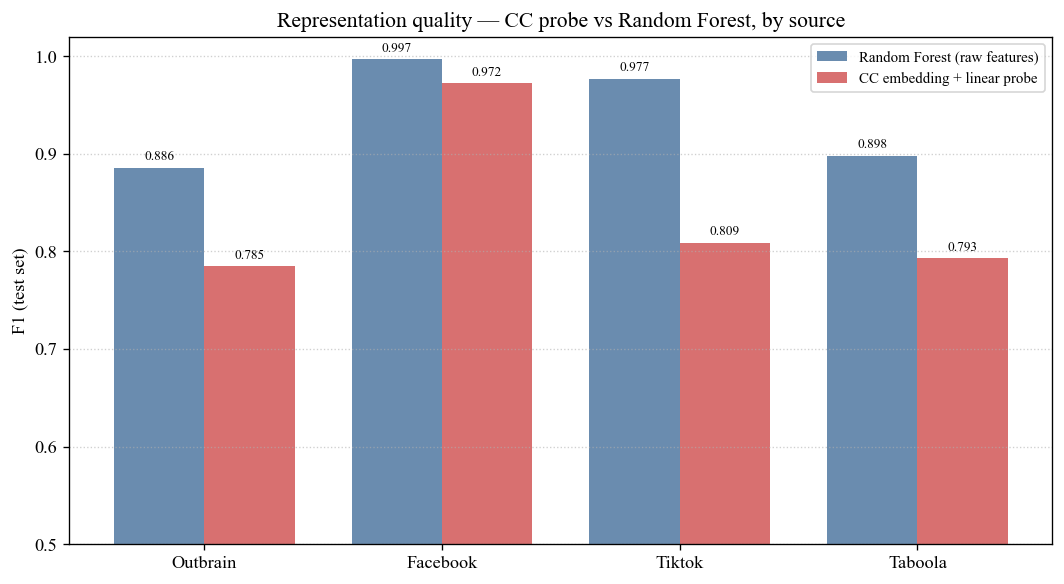

In [8]:
rf_f1  = [results[s]['summary']['rf_f1']     for s in SOURCES]
cc_f1  = [results[s]['summary']['cc_probe_f1'] for s in SOURCES]
x = np.arange(len(SOURCES)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, rf_f1, w, color=SOFT_BLUE, label='Random Forest (raw features)')
ax.bar(x + w/2, cc_f1, w, color=SOFT_RED,  label='CC embedding + linear probe')
ax.set_xticks(x); ax.set_xticklabels([s.capitalize() for s in SOURCES])
ax.set_ylabel('F1 (test set)'); ax.set_ylim(0.5, 1.02)
ax.set_title('Representation quality — CC probe vs Random Forest, by source')
ax.legend(fontsize=9); ax.grid(axis='y', linestyle=':', alpha=0.6)
for xi, v in zip(x - w/2, rf_f1): ax.text(xi, v+0.008, f'{v:.3f}', ha='center', fontsize=8)
for xi, v in zip(x + w/2, cc_f1): ax.text(xi, v+0.008, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout(); savefig('cs_fig2_cc_vs_rf.pdf'); plt.show()


## 4. Clustering and collapse diagnostics across sources

CC's clustering agreement with the labels (ARI) and the number of non-empty
clusters — the collapse guard. The entropy regulariser should keep all `k`
clusters populated on every source.

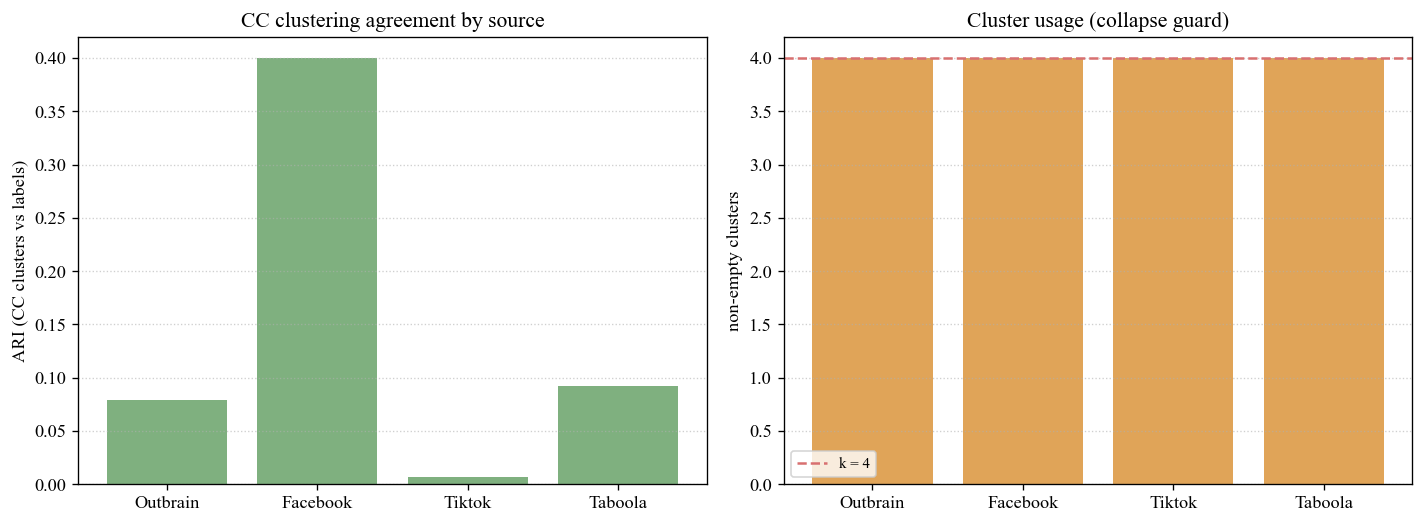

In [9]:
cc_ari   = [results[s]['summary']['cc_clustering_ari']   for s in SOURCES]
cc_kfull = [results[s]['summary']['cc_nonempty_clusters'] for s in SOURCES]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar([s.capitalize() for s in SOURCES], cc_ari, color=SOFT_GREEN)
axes[0].set_ylabel('ARI (CC clusters vs labels)'); axes[0].set_title('CC clustering agreement by source')
axes[0].grid(axis='y', linestyle=':', alpha=0.6)
axes[1].bar([s.capitalize() for s in SOURCES], cc_kfull, color=SOFT_ORANGE)
axes[1].axhline(CC_CLUSTERS, color=SOFT_RED, linestyle='--', label=f'k = {CC_CLUSTERS}')
axes[1].set_ylabel('non-empty clusters'); axes[1].set_title('Cluster usage (collapse guard)')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout(); savefig('cs_fig3_cc_clustering.pdf'); plt.show()


## 5. Synthetic-noise detection across sources — the validated axis

The ensemble suspicion score's ROC-AUC against the **known** noise mask, per
source and noise rate. This is the only axis with a ground truth, so it is where
we can honestly claim the detector *works* — and check whether it works equally
well on every source.

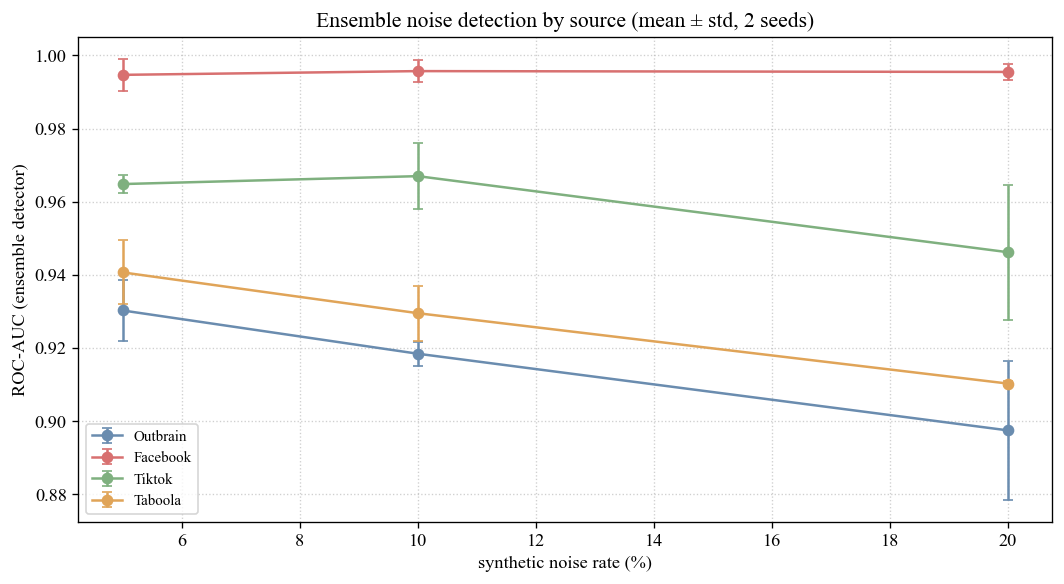

In [10]:
# load each source's synthetic_noise.csv (saved by run_source_study)
syn = pd.concat([
    pd.read_csv(os.path.join(results[s]['out_dir'], 'synthetic_noise.csv'))
    for s in SOURCES], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 5))
for j, s in enumerate(SOURCES):
    sub = (syn[(syn.source == s) & (syn.score == 'ensemble')]
           .groupby('rate')['roc_auc'].agg(['mean', 'std']).reindex(NOISE_RATES))
    ax.errorbar([r*100 for r in NOISE_RATES], sub['mean'], yerr=sub['std'], marker='o',
                capsize=3, color=PALETTE[j], label=s.capitalize())
ax.set_xlabel('synthetic noise rate (%)'); ax.set_ylabel('ROC-AUC (ensemble detector)')
ax.set_title(f'Ensemble noise detection by source (mean ± std, {len(SEEDS)} seeds)')
ax.legend(fontsize=9); ax.grid(linestyle=':', alpha=0.6)
plt.tight_layout(); savefig('cs_fig4_noise_roc_by_source.pdf'); plt.show()


In [11]:
# ROC-AUC of every score, averaged over rates and seeds: score x source
SCORES = ['confident_learning','knn_raw','knn_cc','cc_cluster_entropy',
          'cc_view_instability','centroid_relative_distance','ensemble']
noise_tbl = (syn.groupby(['score','source'])['roc_auc'].mean()
             .unstack().reindex(index=SCORES, columns=SOURCES))
noise_tbl.columns = [s.capitalize() for s in SOURCES]
noise_tbl.index.name = 'Suspicion score (ROC-AUC)'
noise_tbl.round(3)


,Outbrain,Facebook,Tiktok,Taboola
Suspicion score (ROC-AUC),,,,
confident_learning,0.902,0.991,0.976,0.909
knn_raw,0.909,0.993,0.930,0.934
knn_cc,0.900,0.993,0.896,0.895
cc_cluster_entropy,0.494,0.504,0.502,0.511
cc_view_instability,0.490,0.487,0.491,0.514
centroid_relative_distance,0.782,0.964,0.733,0.792
ensemble,0.915,0.995,0.959,0.927


## 6. KNN noise detection — raw features vs CC embedding, across sources

The honest, data-dependent question: does the CC embedding sharpen
neighbourhood-based noise detection relative to the raw feature space — and is the
answer the same on every source?

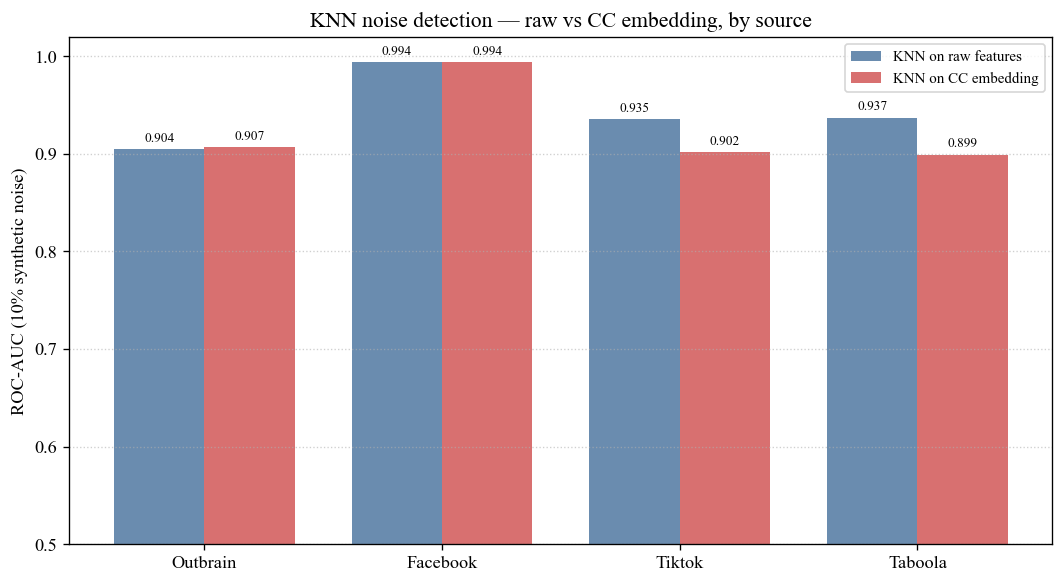

In [12]:
knn = pd.concat([
    pd.read_csv(os.path.join(results[s]['out_dir'], 'knn_comparison.csv'))
    for s in SOURCES], ignore_index=True)
raw_m = [knn[(knn.source==s)&(knn.variant=='KNN raw')]['roc_auc'].mean() for s in SOURCES]
cc_m  = [knn[(knn.source==s)&(knn.variant=='KNN CC')]['roc_auc'].mean()  for s in SOURCES]
x = np.arange(len(SOURCES)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, raw_m, w, color=SOFT_BLUE, label='KNN on raw features')
ax.bar(x + w/2, cc_m,  w, color=SOFT_RED,  label='KNN on CC embedding')
ax.set_xticks(x); ax.set_xticklabels([s.capitalize() for s in SOURCES])
ax.set_ylabel('ROC-AUC (10% synthetic noise)'); ax.set_ylim(0.5, 1.02)
ax.set_title('KNN noise detection — raw vs CC embedding, by source')
ax.legend(fontsize=9); ax.grid(axis='y', linestyle=':', alpha=0.6)
for xi, v in zip(x - w/2, raw_m): ax.text(xi, v+0.008, f'{v:.3f}', ha='center', fontsize=8)
for xi, v in zip(x + w/2, cc_m):  ax.text(xi, v+0.008, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout(); savefig('cs_fig5_knn_raw_vs_cc_by_source.pdf'); plt.show()


## 7. Real-data label audit across sources

No ground truth here — these are *candidates for review*. We compare the Confident
Learning flag rate (a lower bound on suspected mislabels) and the high-precision
heuristic bot count across sources. A source where the detector itself disagrees
with many labels is a source whose labels deserve more scrutiny.

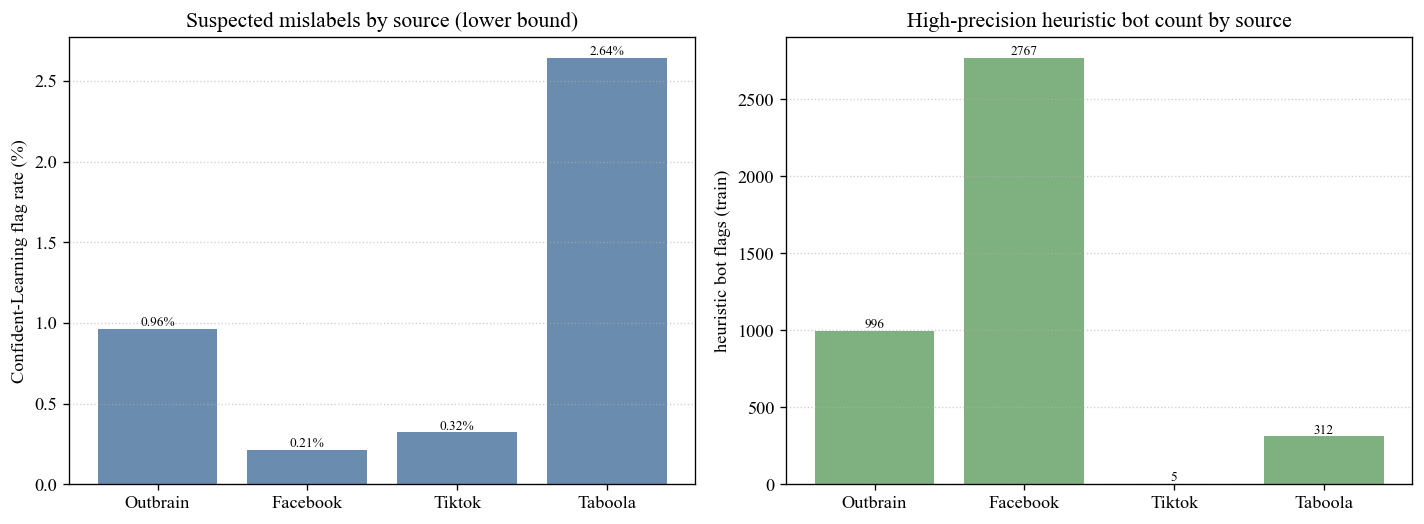

In [13]:
cl_rate = [results[s]['summary']['confident_learning_flag_rate']*100 for s in SOURCES]
heur_n  = [results[s]['summary']['heuristic_bot_flags']               for s in SOURCES]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar([s.capitalize() for s in SOURCES], cl_rate, color=SOFT_BLUE)
axes[0].set_ylabel('Confident-Learning flag rate (%)')
axes[0].set_title('Suspected mislabels by source (lower bound)')
axes[0].grid(axis='y', linestyle=':', alpha=0.6)
for i, v in enumerate(cl_rate): axes[0].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=8)
axes[1].bar([s.capitalize() for s in SOURCES], heur_n, color=SOFT_GREEN)
axes[1].set_ylabel('heuristic bot flags (train)')
axes[1].set_title('High-precision heuristic bot count by source')
axes[1].grid(axis='y', linestyle=':', alpha=0.6)
for i, v in enumerate(heur_n): axes[1].text(i, v, f'{v}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); savefig('cs_fig6_real_audit_by_source.pdf'); plt.show()


## 8. Discussion — method effect vs data-quality effect

Read the figures together:

- **Is the method ranking stable?** Across §2 and §3, if the Random Forest (or
  logistic regression) on raw features is the strongest detector on *every* source
  and the CC probe never overtakes it, then "RF wins" is a property of the
  **method / signal**, not of Outbrain's data quality — the original conclusion
  generalises.
- **Where does data quality show?** Differences in the *absolute* F1 between
  sources (§2) measure how separable bot vs human is in each source. A source that
  pushes every method toward 1.0 simply has an easier, cleaner signal; a source
  where all methods sit lower has noisier or more adversarial traffic. This is the
  data-quality axis, now made explicit and comparable.
- **Does the noise detector travel?** §5–§6 show whether the *validated* synthetic
  detection holds up on every source. A consistently high ensemble ROC-AUC means
  the auditing tool is portable; any source where it drops flags a harder labelling
  regime.
- **Which sources need label scrutiny?** §7's Confident-Learning flag rate and
  heuristic counts rank the sources by how much their labels deserve review — a
  practical, honest output.

**Bottom line.** The comparison separates *the method behaves this way* from *this
one dataset is clean/easy*. The saved artifacts under
`results/cross_source/<source>/` back every figure, so the article can cite exact
numbers per source.

**Honesty.** Every real-data figure is a *ranking of candidates for review*, never
a probability of mislabelling. Detector quality is only ever claimed on the
synthetic axis (§5–§6), where a ground-truth flip mask exists.
